# Empirical Evaluation Analysis

This notebook analyzes the results from the fuzzer evaluation runs.
It loads data from `.jsonl` files generated during the experiments,
processes the data, and generates visualizations to answer the research questions.

## Setup: Import Libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json
import os
import glob
import re
from datetime import datetime, timezone
import numpy as np

## Configuration

In [2]:
# --- User Configuration ---
# Set the base directory containing the evaluation results
# Use 'evaluation_runs-1_run' for the short test data
# Use 'evaluation_runs' for the full data (once available)
BASE_EVALUATION_DIR = 'evaluation_runs-1_run'

# Set the target applications to analyze (will be discovered automatically, but can be filtered)
# Example: TARGETS_TO_ANALYZE = ['django'] or TARGETS_TO_ANALYZE = None to analyze all
TARGETS_TO_ANALYZE = None

# --- Plotting Configuration ---
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
# Use a color palette suitable for the number of configurations
# Adjust 'n_colors' based on the actual number of configs (full, no_coverage, no_prioritization = 3)
palette = sns.color_palette("viridis", n_colors=3)
sns.set_palette(palette)

## Phase 1: Data Loading Functions

Define functions to load data from the experiment output files (`fuzz_exp.jsonl`, `interesting_mutations.jsonl`, `unique_errors.jsonl`).

In [3]:
def parse_log_line(line):
    """Parses a log line with 'timestamp - {json_data}' format."""
    try:
        timestamp_str, json_str = line.split(' - ', 1)
        timestamp = pd.to_datetime(timestamp_str.replace(',', '.'), errors='coerce') # Handle milliseconds
        data = json.loads(json_str)
        # Convert timestamp to UTC if it's naive, assuming local time if not specified
        if timestamp is not pd.NaT and timestamp.tzinfo is None:
             timestamp = timestamp.tz_localize(datetime.now().astimezone().tzinfo).tz_convert(timezone.utc)
        elif timestamp is not pd.NaT:
             timestamp = timestamp.tz_convert(timezone.utc) # Ensure UTC
        data['log_timestamp_utc'] = timestamp
        return data
    except (ValueError, json.JSONDecodeError, AttributeError) as e:
        print(f"Warning: Skipping malformed line: {line.strip()} | Error: {e}")
        return None

def load_jsonl_file(file_path, metadata, parse_line_func=None):
    """Loads a JSONL file, optionally parsing lines and adding metadata."""
    records = []
    print(f"    Loading: {os.path.basename(file_path)}...")
    try:
        with open(file_path, 'r') as f:
            for line in f:
                line = line.strip()
                if not line:
                    continue
                
                data = None
                if parse_line_func:
                    data = parse_line_func(line)
                else:
                    try:
                        data = json.loads(line)
                    except json.JSONDecodeError as e:
                        print(f"Warning: Skipping malformed JSON line in {os.path.basename(file_path)}: {line} | Error: {e}")
                        continue
                
                if data:
                    # Add metadata (target, config, run_id)
                    data.update(metadata)
                    records.append(data)
    except FileNotFoundError:
        print(f"    Warning: File not found: {file_path}")
    except Exception as e:
        print(f"    Error reading file {file_path}: {e}")
    return records

def load_evaluation_data(base_dir, targets_to_analyze=None):
    """
    Loads all relevant .jsonl data from the evaluation directory structure.
    Structure: base_dir / target / config / run_id / *.jsonl
    """
    all_exp_logs = []
    all_interesting_logs = []
    all_error_logs = []

    notebook_cwd = os.getcwd()
    full_base_path = os.path.join(notebook_cwd, base_dir)
    print(f"Scanning base directory: {full_base_path}")

    if not os.path.isdir(full_base_path):
        print(f"Error: Base directory not found: {full_base_path}")
        return pd.DataFrame(), pd.DataFrame(), pd.DataFrame()

    # Iterate through targets
    for target_name in os.listdir(full_base_path):
        target_path = os.path.join(full_base_path, target_name)
        if not os.path.isdir(target_path):
            continue
        if targets_to_analyze and target_name not in targets_to_analyze:
            print(f"Skipping target (not in targets_to_analyze): {target_name}")
            continue
            
        print(f"\nProcessing Target: {target_name}")

        # Iterate through configurations
        for config_name in os.listdir(target_path):
            config_path = os.path.join(target_path, config_name)
            if not os.path.isdir(config_path):
                continue
            print(f"  Processing Config: {config_name}")

            # Iterate through runs
            for run_folder in os.listdir(config_path):
                if not run_folder.startswith('run_'):
                    continue
                
                run_path = os.path.join(config_path, run_folder)
                if not os.path.isdir(run_path):
                    continue

                try:
                    run_id = int(run_folder.split('_')[1])
                except (IndexError, ValueError):
                    print(f"    Warning: Could not parse run_id from folder '{run_folder}', skipping.")
                    continue
                
                print(f"    Processing Run ID: {run_id}")

                metadata = {
                    'target_name': target_name,
                    'config_name': config_name,
                    'run_id': run_id
                }

                # Load fuzz_exp.jsonl
                fuzz_exp_path = os.path.join(run_path, "fuzz_exp.jsonl")
                all_exp_logs.extend(load_jsonl_file(fuzz_exp_path, metadata, parse_line_func=parse_log_line))

                # Load interesting_mutations.jsonl
                interesting_path = os.path.join(run_path, "interesting_mutations.jsonl")
                interesting_records = load_jsonl_file(interesting_path, metadata)
                # Convert timestamp in interesting_mutations if it exists
                for rec in interesting_records:
                     if 'timestamp' in rec:
                         ts = pd.to_datetime(rec['timestamp'], unit='s', errors='coerce')
                         rec['timestamp_utc'] = ts.tz_localize(timezone.utc) if ts is not pd.NaT and ts.tzinfo is None else ts
                all_interesting_logs.extend(interesting_records)


                # Load unique_errors.jsonl
                errors_path = os.path.join(run_path, "unique_errors.jsonl")
                all_error_logs.extend(load_jsonl_file(errors_path, metadata))

    # Create DataFrames
    df_exp = pd.DataFrame(all_exp_logs)
    df_interesting = pd.DataFrame(all_interesting_logs)
    df_errors = pd.DataFrame(all_error_logs)

    print(f"\nLoaded {len(df_exp)} experiment log records.")
    print(f"Loaded {len(df_interesting)} interesting mutation records.")
    print(f"Loaded {len(df_errors)} unique error records.")

    # --- Data Cleaning and Preparation ---

    # Experiment Logs (df_exp)
    if not df_exp.empty:
        # Convert relevant columns to numeric, coercing errors
        exp_numeric_cols = [
            'iteration', 'mutation_index_total', 'seed_s_pre', 'seed_f_pre',
            'mutation_unique_arcs_count', 'new_unique_arcs_count',
            'total_unique_arcs', 'total_unique_paths',
            'total_iterations_completed', 'total_mutations_run',
            'final_total_unique_arcs', 'final_total_unique_paths',
            'final_seed_queue_size', 'final_bug_count' # Note: final_bug_count might be from 'end' event
        ]
        for col in exp_numeric_cols:
            if col in df_exp.columns:
                df_exp[col] = pd.to_numeric(df_exp[col], errors='coerce')
        
        # Ensure timestamp is sorted within each run
        if 'log_timestamp_utc' in df_exp.columns:
             df_exp = df_exp.sort_values(by=['target_name', 'config_name', 'run_id', 'log_timestamp_utc'])
             # Calculate elapsed time
             df_exp['run_start_time'] = df_exp.groupby(['target_name', 'config_name', 'run_id'])['log_timestamp_utc'].transform('min')
             df_exp['elapsed_time'] = df_exp['log_timestamp_utc'] - df_exp['run_start_time']
             df_exp['elapsed_seconds'] = df_exp['elapsed_time'].dt.total_seconds()
             # Fill forward elapsed time for records without timestamps (like header/start)
             df_exp['elapsed_seconds'] = df_exp['elapsed_seconds'].ffill()


    # Interesting Mutations (df_interesting)
    if not df_interesting.empty:
        interesting_numeric_cols = [
            'mutation_index_total', 'new_unique_arcs_count',
            'total_unique_arcs', 'total_unique_paths'
        ]
        for col in interesting_numeric_cols:
            if col in df_interesting.columns:
                df_interesting[col] = pd.to_numeric(df_interesting[col], errors='coerce')
        
        # Sort by timestamp if available
        if 'timestamp_utc' in df_interesting.columns:
            df_interesting = df_interesting.sort_values(by=['target_name', 'config_name', 'run_id', 'timestamp_utc'])
            # Calculate elapsed time relative to experiment start time
            if not df_exp.empty and 'run_start_time' in df_exp.columns:
                 run_starts = df_exp.groupby(['target_name', 'config_name', 'run_id'])['run_start_time'].first().reset_index()
                 df_interesting = pd.merge(df_interesting, run_starts, on=['target_name', 'config_name', 'run_id'], how='left')
                 df_interesting['elapsed_time'] = df_interesting['timestamp_utc'] - df_interesting['run_start_time']
                 df_interesting['elapsed_seconds'] = df_interesting['elapsed_time'].dt.total_seconds()


    # Unique Errors (df_errors) - Primarily for counting final unique bugs per run
    if not df_errors.empty:
        # Add a simple count column for aggregation
        df_errors['error_count'] = 1

    return df_exp, df_interesting, df_errors

## Phase 2: Load Data

Execute the loading function and display basic information about the loaded DataFrames.


In [4]:
df_exp, df_interesting, df_errors = load_evaluation_data(BASE_EVALUATION_DIR, TARGETS_TO_ANALYZE)

print("\n--- Experiment Logs (df_exp) ---")
if not df_exp.empty:
    print(df_exp.info())
    print(df_exp.head())
else:
    print("df_exp is empty.")

print("\n--- Interesting Mutations (df_interesting) ---")
if not df_interesting.empty:
    print(df_interesting.info())
    print(df_interesting.head())
else:
    print("df_interesting is empty.")

print("\n--- Unique Errors (df_errors) ---")
if not df_errors.empty:
    print(df_errors.info())
    print(df_errors.head())
else:
    print("df_errors is empty.")

Scanning base directory: /Users/ansarahmed/Desktop/swt-proj/DjangoWebApplication/evaluation_runs-1_run

Processing Target: django
  Processing Config: full
    Processing Run ID: 1
    Loading: fuzz_exp.jsonl...
    Loading: interesting_mutations.jsonl...
    Loading: unique_errors.jsonl...
  Processing Config: no_prioritization
    Processing Run ID: 1
    Loading: fuzz_exp.jsonl...
    Loading: interesting_mutations.jsonl...
    Loading: unique_errors.jsonl...
  Processing Config: no_coverage
    Processing Run ID: 1
    Loading: fuzz_exp.jsonl...
    Loading: interesting_mutations.jsonl...
    Loading: unique_errors.jsonl...

Loaded 10712 experiment log records.
Loaded 21 interesting mutation records.
Loaded 846 unique error records.

--- Experiment Logs (df_exp) ---
<class 'pandas.core.frame.DataFrame'>
Index: 10712 entries, 0 to 3407
Data columns (total 33 columns):
 #   Column                      Non-Null Count  Dtype              
---  ------                      --------------

# ## Phase 3: Configuration Summary

Display the targets, configurations, and runs found in the loaded data.

In [5]:
if not df_exp.empty:
    print("--- Configuration Summary ---")
    targets = df_exp['target_name'].unique().tolist()
    configs = df_exp['config_name'].unique().tolist()
    runs = sorted(df_exp['run_id'].unique().tolist())
    print(f"Targets Found: {targets}")
    print(f"Configurations Found: {configs}")
    print(f"Run IDs Found: {runs}")
    
    # Display counts per group
    print("\nRecords per Target/Config/Run:")
    print(df_exp.groupby(['target_name', 'config_name', 'run_id']).size())
else:
    print("DataFrame 'df_exp' is empty, cannot display configuration summary.")

--- Configuration Summary ---
Targets Found: ['django']
Configurations Found: ['full', 'no_coverage', 'no_prioritization']
Run IDs Found: [1]

Records per Target/Config/Run:
target_name  config_name        run_id
django       full               1         2104
             no_coverage        1         7304
             no_prioritization  1         1304
dtype: int64


## Phase 4: Analysis & Visualization

Analyze the loaded data to answer the research questions.


### RQ1: Effectiveness
- How many unique bugs does each configuration find? (Using `df_errors`)
- How does the count of 'interesting' inputs grow over time? (Using `df_interesting`)
- How does coverage (unique arcs/paths) increase over time and per mutation? (Using `df_exp` or `df_interesting`)


--- RQ1: Final Unique Bugs ---
Final Unique Bugs Found (per Run):
| target_name   | config_name       |   run_id |   final_unique_bugs |
|:--------------|:------------------|---------:|--------------------:|
| django        | full              |        1 |                 334 |
| django        | no_coverage       |        1 |                 193 |
| django        | no_prioritization |        1 |                 319 |


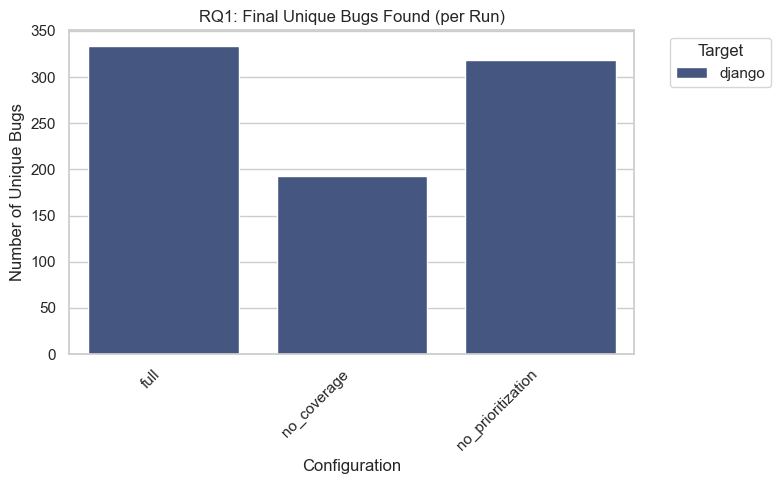

In [6]:
print("\n--- RQ1: Final Unique Bugs ---")
if not df_errors.empty:
    final_bugs = df_errors.groupby(['target_name', 'config_name', 'run_id'])['error_count'].sum().reset_index()
    final_bugs = final_bugs.rename(columns={'error_count': 'final_unique_bugs'})
    print("Final Unique Bugs Found (per Run):")
    print(final_bugs.to_markdown(index=False))

    # Plot final bugs (more meaningful with multiple runs for RQ4)
    plt.figure(figsize=(8, 5))
    sns.barplot(data=final_bugs, x='config_name', y='final_unique_bugs', hue='target_name', dodge=True)
    plt.title('RQ1: Final Unique Bugs Found (per Run)')
    plt.xlabel('Configuration')
    plt.ylabel('Number of Unique Bugs')
    plt.xticks(rotation=45, ha='right')
    plt.legend(title='Target', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()
    
    # Store for later use in RQ4
    rq1_final_bugs = final_bugs.copy()

else:
    print("Skipping RQ1 final bugs analysis: 'df_errors' is empty.")
    rq1_final_bugs = pd.DataFrame() # Ensure variable exists


--- RQ1: Interesting Inputs Over Time ---


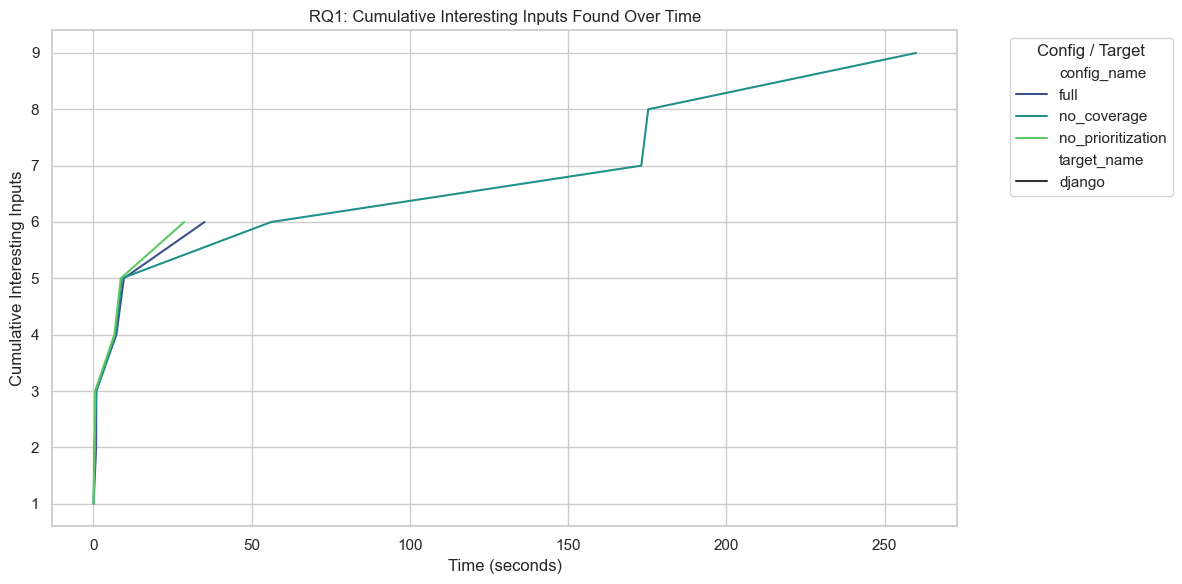

In [7]:
# 2. Cumulative Interesting Inputs vs. Time
print("\n--- RQ1: Interesting Inputs Over Time ---")
if not df_interesting.empty and 'elapsed_seconds' in df_interesting.columns:
    # Ensure data is sorted
    df_interesting_sorted = df_interesting.sort_values(by=['target_name', 'config_name', 'run_id', 'elapsed_seconds'])
    
    # Calculate cumulative count
    df_interesting_sorted['cumulative_interesting'] = df_interesting_sorted.groupby(['target_name', 'config_name', 'run_id']).cumcount() + 1
    
    plt.figure()
    sns.lineplot(data=df_interesting_sorted, x='elapsed_seconds', y='cumulative_interesting',
                 hue='config_name', style='target_name',
                 markers=False, dashes=True, errorbar=('ci', 95)) # Show confidence interval if multiple runs
    
    plt.title('RQ1: Cumulative Interesting Inputs Found Over Time')
    plt.xlabel('Time (seconds)')
    plt.ylabel('Cumulative Interesting Inputs')
    plt.legend(title='Config / Target', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()
    
    # Store final values for RQ4
    last_interesting = df_interesting_sorted.loc[df_interesting_sorted.groupby(['target_name', 'config_name', 'run_id'])['elapsed_seconds'].idxmax()]
    rq1_final_interesting = last_interesting[['target_name', 'config_name', 'run_id', 'cumulative_interesting']].copy()

else:
    print("Skipping RQ1 cumulative interesting inputs plot: 'df_interesting' is empty or missing 'elapsed_seconds'.")
    rq1_final_interesting = pd.DataFrame() # Ensure variable exists



--- RQ1: Coverage (Arcs) Over Time ---


/var/folders/tp/3dlrjscn3xddy6x7k7y4s7yh0000gn/T/ipykernel_72403/4183243643.py:13: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_exp_mutations['total_unique_arcs'] = df_exp_mutations['total_unique_arcs'].fillna(method='ffill')


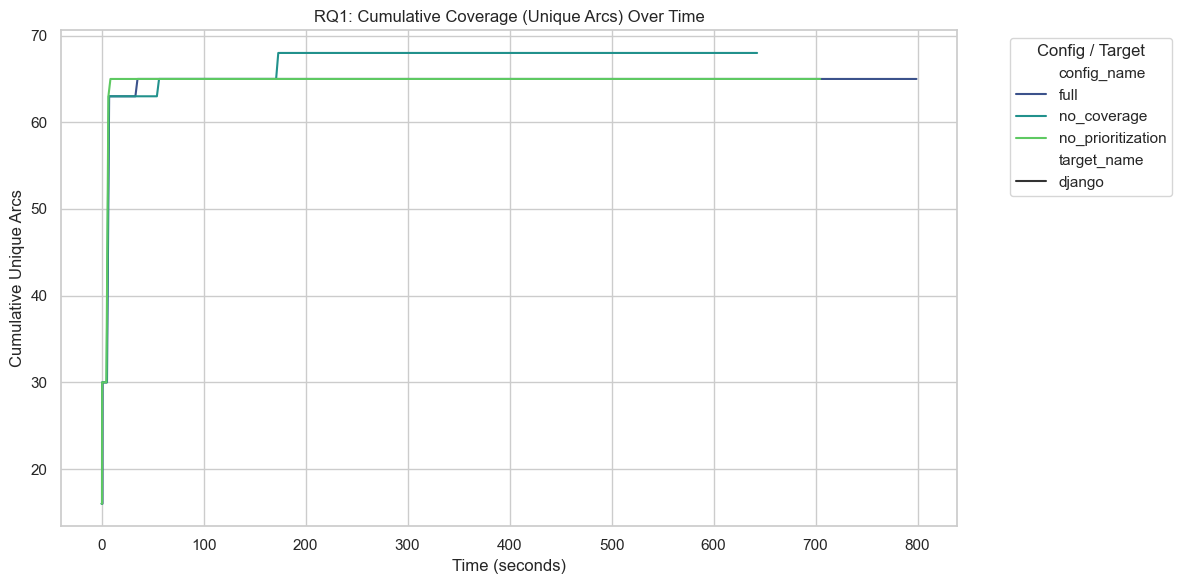

In [8]:
# 3. Cumulative Coverage (Arcs) vs. Time
print("\n--- RQ1: Coverage (Arcs) Over Time ---")
# Use df_exp as it logs progress more frequently, filter for mutation_log events
if not df_exp.empty and 'elapsed_seconds' in df_exp.columns and 'total_unique_arcs' in df_exp.columns:
    df_exp_mutations = df_exp[df_exp['event'] == 'mutation_log'].copy()
    
    if not df_exp_mutations.empty:
        # Ensure data is sorted
        df_exp_mutations = df_exp_mutations.sort_values(by=['target_name', 'config_name', 'run_id', 'elapsed_seconds'])
        
        # Calculate cumulative max unique arcs for each group
        # Need to handle NaNs potentially introduced by non-mutation events if not filtered
        df_exp_mutations['total_unique_arcs'] = df_exp_mutations['total_unique_arcs'].fillna(method='ffill')
        df_exp_mutations['cumulative_max_arcs'] = df_exp_mutations.groupby(['target_name', 'config_name', 'run_id'])['total_unique_arcs'].cummax()
        
        plt.figure()
        sns.lineplot(data=df_exp_mutations, x='elapsed_seconds', y='cumulative_max_arcs',
                     hue='config_name', style='target_name',
                     markers=False, dashes=True, errorbar=('ci', 95))
        
        plt.title('RQ1: Cumulative Coverage (Unique Arcs) Over Time')
        plt.xlabel('Time (seconds)')
        plt.ylabel('Cumulative Unique Arcs')
        plt.legend(title='Config / Target', bbox_to_anchor=(1.05, 1), loc='upper left')
        plt.tight_layout()
        plt.show()
        
        # Store final values for RQ4
        last_arc_records = df_exp_mutations.loc[df_exp_mutations.groupby(['target_name', 'config_name', 'run_id'])['elapsed_seconds'].idxmax()]
        rq1_final_arcs = last_arc_records[['target_name', 'config_name', 'run_id', 'cumulative_max_arcs']].copy()
        
    else:
        print("No 'mutation_log' events found in df_exp to plot coverage.")
        rq1_final_arcs = pd.DataFrame()

else:
    print("Skipping RQ1 cumulative coverage plot: 'df_exp' is empty or missing required columns ('elapsed_seconds', 'total_unique_arcs').")
    rq1_final_arcs = pd.DataFrame() # Ensure variable exists



--- RQ1: Coverage (Arcs) vs. Mutations ---


/var/folders/tp/3dlrjscn3xddy6x7k7y4s7yh0000gn/T/ipykernel_72403/4277761230.py:12: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_exp_mutations_idx['total_unique_arcs'] = df_exp_mutations_idx['total_unique_arcs'].fillna(method='ffill')


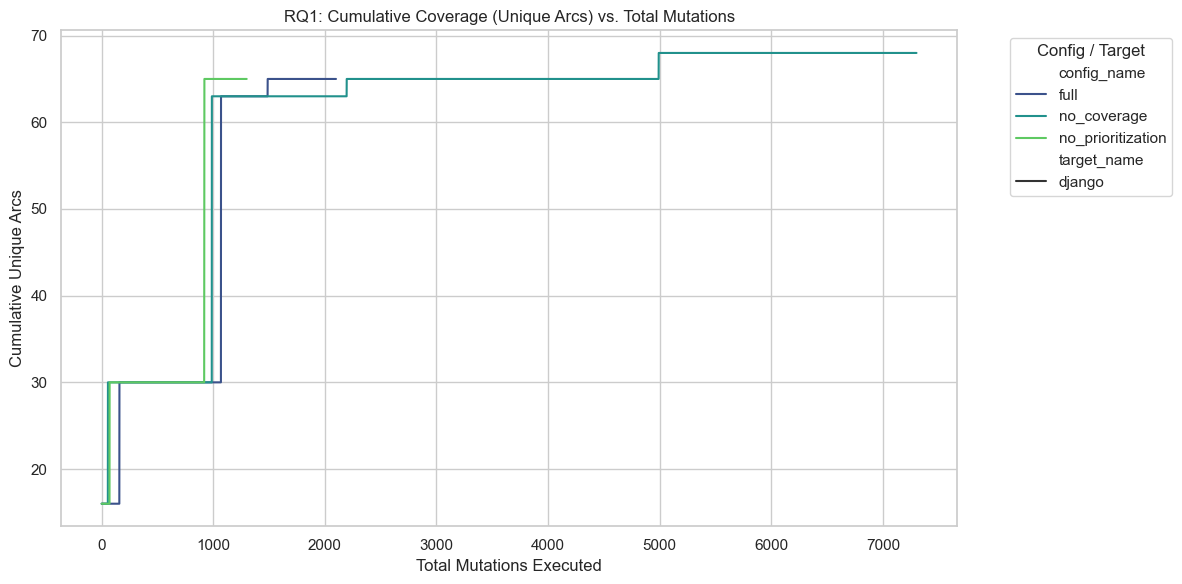

In [9]:
# 4. Cumulative Coverage (Arcs) vs. Mutations Executed
print("\n--- RQ1: Coverage (Arcs) vs. Mutations ---")
# Use 'mutation_index_total' as the x-axis
if not df_exp.empty and 'mutation_index_total' in df_exp.columns and 'total_unique_arcs' in df_exp.columns:
    df_exp_mutations_idx = df_exp[df_exp['event'] == 'mutation_log'].copy()
    
    if not df_exp_mutations_idx.empty:
         # Ensure data is sorted by mutation index
        df_exp_mutations_idx = df_exp_mutations_idx.sort_values(by=['target_name', 'config_name', 'run_id', 'mutation_index_total'])
        
        # Calculate cumulative max unique arcs vs mutation index
        df_exp_mutations_idx['total_unique_arcs'] = df_exp_mutations_idx['total_unique_arcs'].fillna(method='ffill')
        df_exp_mutations_idx['cumulative_max_arcs'] = df_exp_mutations_idx.groupby(['target_name', 'config_name', 'run_id'])['total_unique_arcs'].cummax()
        
        plt.figure()
        sns.lineplot(data=df_exp_mutations_idx, x='mutation_index_total', y='cumulative_max_arcs',
                     hue='config_name', style='target_name',
                     markers=False, dashes=True, errorbar=('ci', 95))
        
        plt.title('RQ1: Cumulative Coverage (Unique Arcs) vs. Total Mutations')
        plt.xlabel('Total Mutations Executed')
        plt.ylabel('Cumulative Unique Arcs')
        plt.legend(title='Config / Target', bbox_to_anchor=(1.05, 1), loc='upper left')
        plt.tight_layout()
        plt.show()
    else:
         print("No 'mutation_log' events found in df_exp to plot coverage vs mutations.")

else:
    print("Skipping RQ1 cumulative coverage vs mutations plot: 'df_exp' is empty or missing required columns ('mutation_index_total', 'total_unique_arcs').")


### RQ2: Efficiency
- How long does it take to find the first bug? (Needs timestamped bug data - approximating with first *interesting mutation*)
- What is the average time spent on test generation vs. execution? (Data not available in provided logs)


In [10]:
# --- RQ2: Efficiency ---

# 1. Time to First Interesting Mutation (Proxy for First Bug)
print("\n--- RQ2: Time to First Interesting Mutation ---")
if not df_interesting.empty and 'elapsed_seconds' in df_interesting.columns:
    # Find the first record for each run
    first_interesting = df_interesting.loc[df_interesting.groupby(['target_name', 'config_name', 'run_id'])['elapsed_seconds'].idxmin()]
    
    time_to_first = first_interesting[['target_name', 'config_name', 'run_id', 'elapsed_seconds']]
    time_to_first = time_to_first.rename(columns={'elapsed_seconds': 'time_to_first_interesting_s'})
    
    print("Time to First Interesting Mutation (per Run):")
    if not time_to_first.empty:
        print(time_to_first.to_markdown(index=False))
        
        # Calculate and display average per config if multiple runs exist
        if len(time_to_first['run_id'].unique()) > 1:
             avg_time_to_first = time_to_first.groupby(['target_name', 'config_name'])['time_to_first_interesting_s'].mean().reset_index()
             print("\nAverage Time to First Interesting Mutation (per Config):")
             print(avg_time_to_first.to_markdown(index=False))
    else:
        print("No interesting mutations found, or 'elapsed_seconds' missing.")
        
else:
    print("Skipping RQ2 time to first interesting mutation: 'df_interesting' is empty or missing 'elapsed_seconds'.")


--- RQ2: Time to First Interesting Mutation ---
Time to First Interesting Mutation (per Run):
| target_name   | config_name       |   run_id |   time_to_first_interesting_s |
|:--------------|:------------------|---------:|------------------------------:|
| django        | full              |        1 |                     0.0446572 |
| django        | no_coverage       |        1 |                     0.0467958 |
| django        | no_prioritization |        1 |                     0.051419  |


In [11]:
# 2. TODO: Generation vs Execution Time
print("\n--- RQ2: Generation vs Execution Time ---")
print("Data for test generation time vs. execution time is not available in the provided log formats.")
print("Skipping this analysis.")


--- RQ2: Generation vs Execution Time ---
Data for test generation time vs. execution time is not available in the provided log formats.
Skipping this analysis.


### RQ3: Baseline Comparison

- How do the ablation study variants perform compared to the full configuration?
- How does the full configuration perform compared to a random baseline (if available)?

**Interpretation:** Compare the performance lines in the **RQ1 plots** above.
- **Ablation Study:** Compare lines for `full`, `no_coverage`, `no_prioritization` configurations on the target plots (Interesting Inputs vs. Time, Coverage vs. Time, Coverage vs. Mutations). Assess the impact of removing coverage feedback or seed prioritization.
- **Baseline Comparison:** If a `random` configuration exists, compare its line against the `full` configuration line across relevant RQ1 plots.

### RQ4: Stability
- How consistent are the results (bugs, interesting inputs, coverage) across multiple runs of the same configuration?

**Note:** These plots are most meaningful when multiple runs (`run_id` > 1) are available for each configuration.



--- RQ4: Stability Analysis (Box Plots) ---
Only single runs detected. Box plots will show single points.


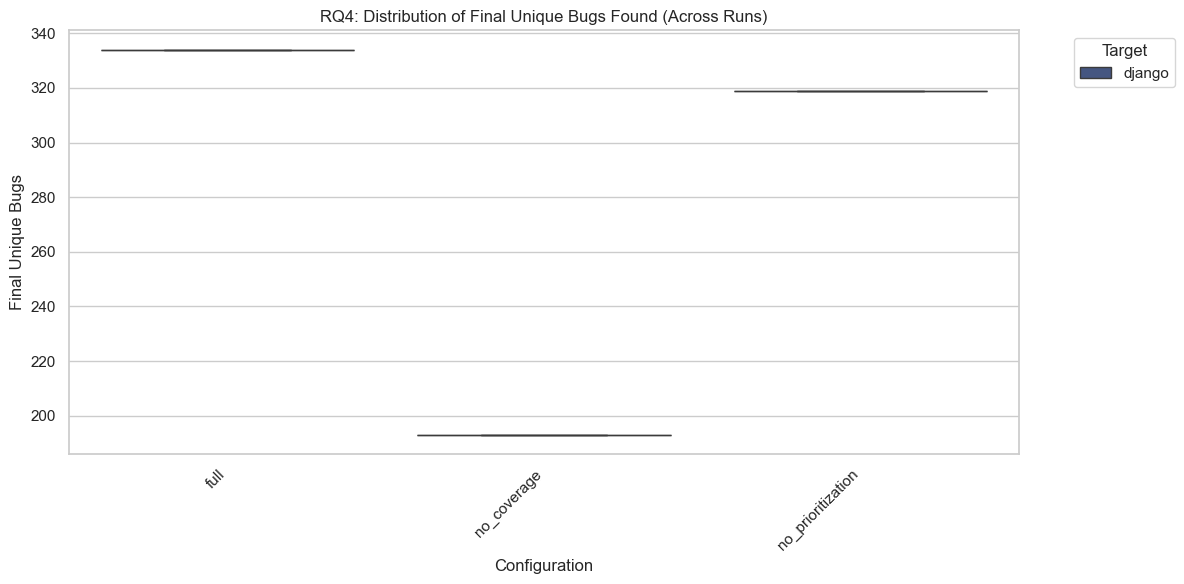

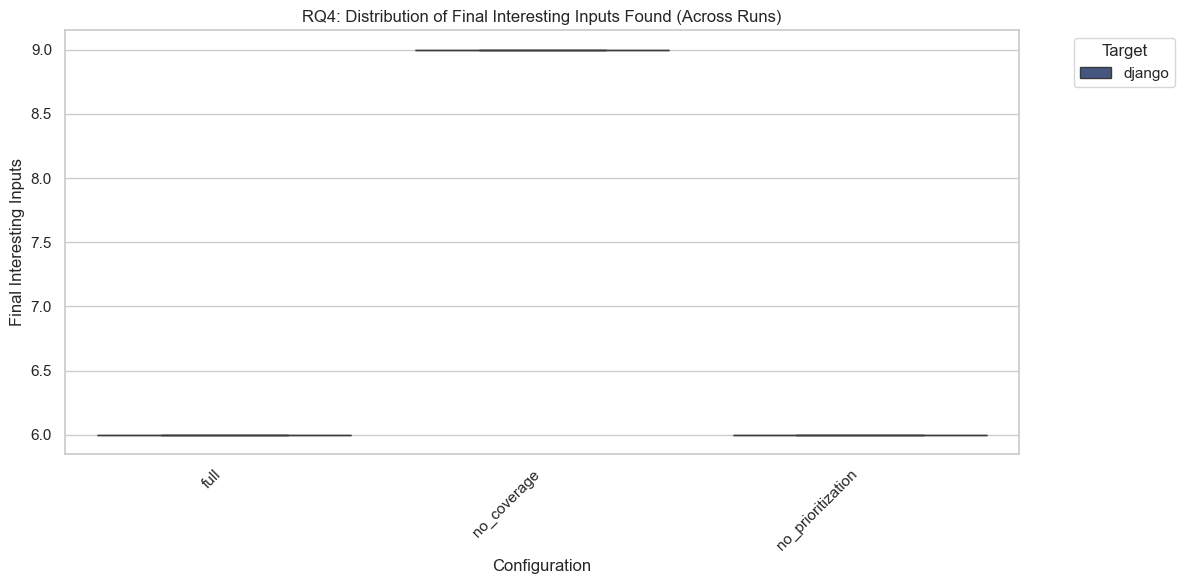

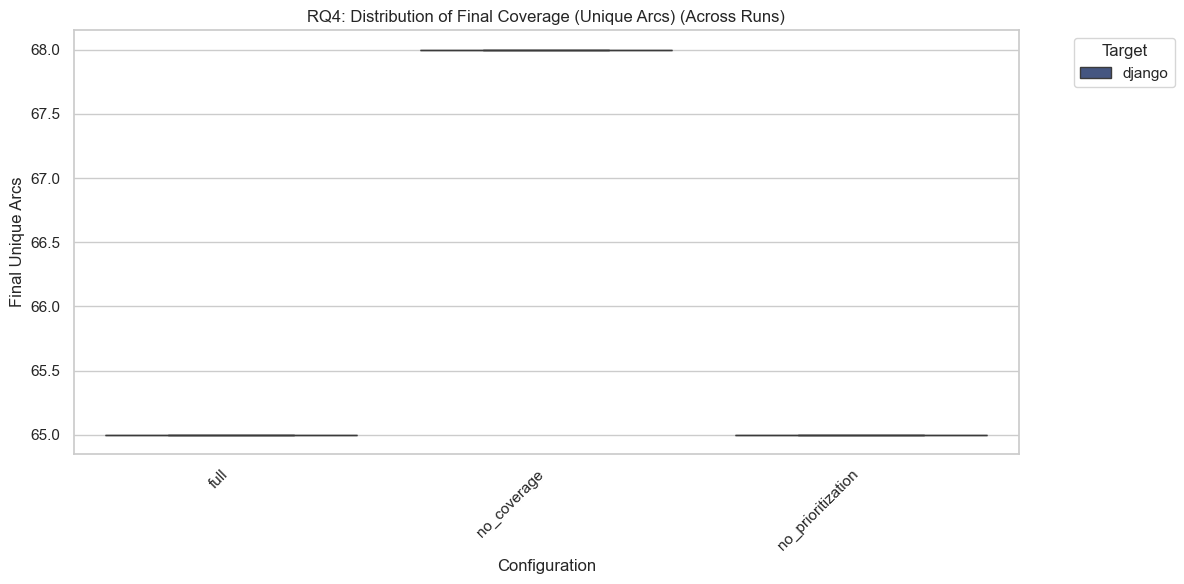

In [13]:
# --- RQ4: Stability ---
print("\n--- RQ4: Stability Analysis (Box Plots) ---")
# Requires results from RQ1 (final bugs, interesting, arcs)

# Check if multiple runs exist
multiple_runs_exist = False
if not df_exp.empty:
    run_counts = df_exp.groupby(['target_name', 'config_name'])['run_id'].nunique()
    if any(run_counts > 1):
        multiple_runs_exist = True
        print("Multiple runs detected. Generating stability plots.")
    else:
        print("Only single runs detected. Box plots will show single points.")

# 1. Box plot for final unique bugs
if not rq1_final_bugs.empty:
    plt.figure()
    sns.boxplot(data=rq1_final_bugs, x='config_name', y='final_unique_bugs', hue='target_name')
    if multiple_runs_exist:
       sns.stripplot(data=rq1_final_bugs, x='config_name', y='final_unique_bugs', hue='target_name', dodge=True, jitter=True, size=3, color=".3")
    plt.title('RQ4: Distribution of Final Unique Bugs Found (Across Runs)')
    plt.xlabel('Configuration')
    plt.ylabel('Final Unique Bugs')
    plt.xticks(rotation=45, ha='right')
    plt.legend(title='Target', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()
else:
    print("Skipping RQ4 final bugs plot: Data not available from RQ1.")

# 2. Box plot for final interesting inputs
if not rq1_final_interesting.empty:
    plt.figure()
    sns.boxplot(data=rq1_final_interesting, x='config_name', y='cumulative_interesting', hue='target_name')
    if multiple_runs_exist:
        sns.stripplot(data=rq1_final_interesting, x='config_name', y='cumulative_interesting', hue='target_name', dodge=True, jitter=True, size=3, color=".3")
    plt.title('RQ4: Distribution of Final Interesting Inputs Found (Across Runs)')
    plt.xlabel('Configuration')
    plt.ylabel('Final Interesting Inputs')
    plt.xticks(rotation=45, ha='right')
    plt.legend(title='Target', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()
else:
    print("Skipping RQ4 final interesting inputs plot: Data not available from RQ1.")

# 3. Box plot for final coverage (arcs)
if not rq1_final_arcs.empty:
    plt.figure()
    sns.boxplot(data=rq1_final_arcs, x='config_name', y='cumulative_max_arcs', hue='target_name')
    if multiple_runs_exist:
       sns.stripplot(data=rq1_final_arcs, x='config_name', y='cumulative_max_arcs', hue='target_name', dodge=True, jitter=True, size=3, color=".3")
    plt.title('RQ4: Distribution of Final Coverage (Unique Arcs) (Across Runs)')
    plt.xlabel('Configuration')
    plt.ylabel('Final Unique Arcs')
    plt.xticks(rotation=45, ha='right')
    plt.legend(title='Target', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()
else:
    print("Skipping RQ4 final coverage plot: Data not available from RQ1.")



## Phase 5: Interpretation